In [2]:
import subprocess
subprocess.run(["pip", "install", "nltk"])
print("Done!")

Done!


In [3]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("Imports done!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ramki\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ramki\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ramki\AppData\Roaming\nltk_data...


Imports done!


In [4]:
# Cell 2 — load raw data
df = pd.read_csv("E:/Research Paper topic/data/raw_papers.csv")
print("Shape:", df.shape)
df.head(3)

Shape: (300, 7)


,title,abstract,year,authors,venue,citations,category
0,BORA: Bridging Offline Reinforcement Learning ...,Vision-Language-Action (VLA) models have emerg...,2026,"Zhongxi Chen, Yifan Han, Yanming Shao, Huanmin...",arXiv,0,cs.RO
1,Sample-Efficient Diffusion-based Reinforcement...,Recent advances in reinforcement learning (RL)...,2026,"Shutong Ding, Zejia Zhong, Zhongyi Wang, Ke Hu...",arXiv,0,cs.RO
2,LLM-Guided Future Hypotheses for Horizon-Aware...,Multi-step robot manipulation requires acting ...,2026,"Mohammad Khoshnazar, Andrew Melnik, Michael Beetz",arXiv,0,cs.RO


In [5]:
# Cell 3 — define cleaning function
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

print("Cleaning function ready!")

Cleaning function ready!


In [6]:
# Cell 4 — clean the data
df = df.dropna(subset=['abstract'])
df['text'] = df['title'].fillna('') + ". " + df['abstract'].fillna('')
df['clean_text'] = df['text'].apply(clean_text)

print("Cleaning done!")
print("\nOriginal text sample:")
print(df['text'][0][:200])
print("\nCleaned text sample:")
print(df['clean_text'][0][:200])

Cleaning done!

Original text sample:
BORA: Bridging Offline Reinforcement Learning and Online Residual Adaptation for Real-World Dexterous VLA Models. Vision-Language-Action (VLA) models have emerged as a promising paradigm for grounding

Cleaned text sample:
bora bridging offline reinforcement learning online residual adaptation realworld dexterous vla model visionlanguageaction vla model emerged promising paradigm grounding visuallanguage understanding r


In [7]:
# Cell 5 — save
df.to_csv("E:/Research Paper topic/data/processed_papers.csv", index=False)
print("Saved", len(df), "papers to processed_papers.csv")

Saved 300 papers to processed_papers.csv


Average text length: 1201


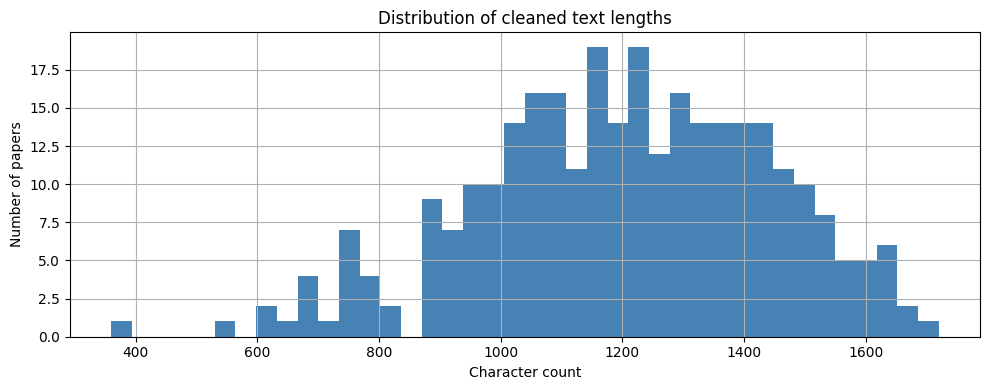

In [8]:
# Cell 6 — visualize
df['text_length'] = df['clean_text'].apply(len)
print("Average text length:", round(df['text_length'].mean()))

df['text_length'].hist(bins=40, figsize=(10, 4), color='steelblue')
plt.title("Distribution of cleaned text lengths")
plt.xlabel("Character count")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()